# 10 — Masked pooled statistics: cloud handling without fill

Cloud pixels are NaN in the raw tifs and are chip-mean filled before encoding, so
parcels under cloud carry fabricated content; 74 of 600 pre-hurricane S2 chips are
near-fully masked and their latents are encoded from pure fill (concentrated in
P03/P06). Notebook 05 showed *generation* fill (whole-chip TerraMind S1→S2) damages the
pooled representations. This notebook tests the opposite direction — **don't fill:
pool only over valid parcels** (the partial-convolution principle: renormalize over the
valid support). Design approved 2026-08-27.

Three labels, identical estimator (their FSC/aFSC R code via `fsc_bridge.R`), identical
donors (covariate-matched 5), identical schemes (frozen_joint + expanding):

- **`unmasked`** — `run_scheme` re-run here as the baseline, so the comparison shares
  one λ-grid convention (the existing notebook 07–09 CSVs used `run_arm`, frozen only).
- **`masked`** (arm 1) — same panel, same periods; per chip, quantiles/Gram/means pool
  over parcels with ≥ 0.5 of their pixels finite, when the chip has ≥ 10 such parcels;
  below that the chip FALLS BACK to all-196 pooling (recorded). Isolates the pooling
  change.
- **`maskdrop`** (arm 2) — additionally, chips below 10 valid parcels become MISSING:
  each group fits on its own surviving pre-periods (3–6 of 8), per-group R calls.
  Isolates the fabricated-chip change. P09/P10 survive for all 10 groups.

Sentinel-2 only: S1 chips are ~99.9% valid, so masked pooling is a no-op there.
Known limitation, stated up front: the tokenizer is a ViT with global attention, so
even valid parcels' tokens saw the filled regions at encode time (§7 of the 8-27 doc
measured tokens as strongly local, R² 0.65–0.82, so this is second-order). Masked
pooling reduces fill contamination; it cannot remove it.

In [1]:
import sys, time
import numpy as np
import pandas as pd

sys.path.insert(0, ".")
import panel_lib as pl
import panel_repr as pr
import panel_fsc as pf

pl.set_plot_style()
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 60)

SENSOR = "sentinel2"
REPRS = ["chip_mean", "quantile", "gram", "combined"]
METHOD = "covmat"

panel = pl.Panel.from_npz(pl.LATD / "latents_biweekly.npz")
if not pr.VALIDITY_NPZ.exists():
    pr.build_validity(pl.build_panel_index())
VAL = pr.load_validity()
print(f"latents={len(panel.flat)}  validity maps={len(VAL)}  thr={pr.PARCEL_THR}  "
      f"min_valid={pr.MIN_VALID}")

nv = pd.DataFrame([{"site": s, "seq": q,
                    "n_valid": pr.n_valid(VAL, panel, s, SENSOR, q)}
                   for s in panel.roster["site_id"] for q in range(1, 21)
                   if panel.have(s, SENSOR, q) and panel.observed(s, SENSOR, q)])
print("\nS2 valid parcels /196 by period (mean, and chips <10):")
g = nv.groupby("seq")["n_valid"].agg(["mean", lambda x: (x < pr.MIN_VALID).sum()])
g.columns = ["mean_valid", "n_chips_below_min"]
print(g.round(1).T.to_string())

latents=2322  validity maps=2322  thr=0.5  min_valid=10

S2 valid parcels /196 by period (mean, and chips <10):
seq                   1      2     3      4      5     6      7      8      9      10     11     12    13    14    15     16    17    18     19     20
mean_valid         144.3  128.7  35.3  155.3  174.0  44.6  120.4  179.5  139.4  192.8  196.0  196.0  52.9  90.0  16.3  120.3  41.2  58.2  165.5  186.1
n_chips_below_min    5.0   11.0  40.0    2.0    0.0  27.0    8.0    0.0    0.0    0.0    0.0    0.0  33.0  10.0  29.0    3.0  30.0  14.0    0.0    0.0


## 1. Fits — unmasked baseline, masked (arm 1), maskdrop (arm 2)

In [2]:
def masked_builder(p, sensor, name, groups, periods, grids=pr.GRIDS_Q):
    return pr.build_block_masked(p, sensor, name, groups, periods, VAL, grids=grids)

RUNS, MET = {}, []
for name in REPRS:
    for label, kw in (("unmasked", {}), ("masked", {"block_builder": masked_builder})):
        t0 = time.time()
        R = pf.run_scheme(panel, SENSOR, name, METHOD, label, **kw)
        RUNS[(label, name)] = R
        MET.append(R["metrics"])
        print(f"{label:9s} {name:10s} M={R['block'].shape[-1]:3d} "
              f"groups={len(R['groups'])} ({time.time()-t0:.0f}s)")
    t0 = time.time()
    R2 = pf.run_scheme_pergroup(panel, SENSOR, name, METHOD, "maskdrop", VAL)
    RUNS[("maskdrop", name)] = R2
    MET.append(R2["metrics"])
    print(f"{'maskdrop':9s} {name:10s} groups={R2['group_meta'].shape[0]} "
          f"dropped={len(R2['dropped'])} ({time.time()-t0:.0f}s)")
MET = pd.concat(MET, ignore_index=True)

info = pr.build_block_masked(panel, SENSOR, "chip_mean",
                             RUNS[("masked", "chip_mean")]["groups"],
                             RUNS[("masked", "chip_mean")]["periods"], VAL)[2]
print(f"\narm-1 fallback chips (all-196 pooling): {(~info['masked']).sum()} of "
      f"{len(info)};  by period: "
      f"{info.query('~masked').groupby('seq').size().to_dict()}")
print("\narm-2 per-group fit periods:")
print(RUNS[("maskdrop", "chip_mean")]["group_meta"].to_string(index=False))

unmasked  chip_mean  M=  5 groups=10 (8s)


masked    chip_mean  M=  5 groups=10 (8s)


maskdrop  chip_mean  groups=10 dropped=0 (58s)


unmasked  quantile   M=100 groups=10 (141s)


masked    quantile   M=100 groups=10 (141s)


...

masked    gram       M= 15 groups=10 (12s)


maskdrop  gram       groups=10 dropped=0 (60s)


unmasked  combined   M=115 groups=10 (213s)


masked    combined   M=115 groups=10 (214s)


maskdrop  combined   groups=10 dropped=0 (98s)

arm-1 fallback chips (all-196 pooling): 183 of 1140;  by period: {1: 5, 2: 11, 3: 40, 4: 2, 6: 27, 7: 8, 13: 33, 14: 10, 16: 3, 17: 30, 18: 14}

arm-2 per-group fit periods:
 group treatment_site_id  n_pre        pre_periods  n_post
     1    treatment_0001      6 [1, 2, 4, 5, 7, 8]       5
     2    treatment_0002      4       [2, 4, 5, 8]       7
     3    treatment_0003      4       [1, 2, 5, 8]       6
     4    treatment_0004      4       [4, 5, 7, 8]       5
     5    treatment_0005      5    [1, 2, 5, 7, 8]       5
     6    treatment_0006      3          [4, 5, 8]       7
     7    treatment_0007      5    [1, 4, 5, 7, 8]       6
     8    treatment_0008      5    [1, 4, 5, 7, 8]       5
     9    treatment_0009      5    [1, 4, 5, 7, 8]       4
    10    treatment_0010      5    [1, 4, 5, 7, 8]       6


## 2. Holdout validation — does masking help?

Metric: `ratio_own_mean` = prediction RMSE ÷ RMSE of the treated site's own
pre-period mean (no donors). Below 1 = the donors added something. Ratios are
internally consistent per label (each divides by a null computed on the same
representation of the same panel), so they ARE comparable across labels.

In [3]:
ex = MET.query("scheme == 'expanding'")
piv = (ex.pivot_table(index=["repr", "estimator"], columns=["label", "eval_period"],
                      values="ratio_own_mean", aggfunc="mean")
       .reindex(REPRS, level=0)
       .reindex(columns=["unmasked", "masked", "maskdrop"], level=0).round(3))
print("mean ratio_own_mean, expanding scheme (w8->P09, w9->P10):")
print(piv.to_string())

beat = (ex.assign(beat=ex.ratio_own_mean < 1)
        .pivot_table(index=["repr", "estimator"], columns=["label", "eval_period"],
                     values="beat", aggfunc="sum")
        .reindex(REPRS, level=0)
        .reindex(columns=["unmasked", "masked", "maskdrop"], level=0).astype(int))
print("\nsites (of 10) beating their own pre-mean:")
print(beat.to_string())

fj = (MET.query("scheme == 'frozen_joint'")
      .pivot_table(index=["repr", "estimator"], columns=["label", "eval_period"],
                   values="ratio_own_mean", aggfunc="mean")
      .reindex(REPRS, level=0)
      .reindex(columns=["unmasked", "masked", "maskdrop"], level=0).round(3))
print("\nfrozen_joint (weights fit once on the pre window):")
print(fj.to_string())

mean ratio_own_mean, expanding scheme (w8->P09, w9->P10):
label               unmasked        masked        maskdrop       
eval_period              P09    P10    P09    P10      P09    P10
repr      estimator                                              
chip_mean afsc         0.702  0.665  1.194  0.502    1.606  0.464
          fsc          0.702  0.665  1.194  0.502    1.504  0.472
quantile  afsc         0.825  0.548  0.911  0.565    1.201  0.649
          fsc          0.825  0.548  0.911  0.565    1.203  0.650
gram      afsc         0.698  0.554  1.284  0.435    1.580  0.446
          fsc          0.698  0.554  1.284  0.435    1.529  0.461
combined  afsc         0.803  0.546  0.931  0.543    1.226  0.622
          fsc          0.803  0.546  0.931  0.543    1.228  0.624

sites (of 10) beating their own pre-mean:
label               unmasked     masked     maskdrop    
eval_period              P09 P10    P09 P10      P09 P10
repr      estimator                                     
ch

## 3. Placebo — Abadie in-space ranks at P11, combined binomial

In [4]:
def scheme_placebo(R, label, name, q=11):
    periods = R["periods"]
    if q not in periods:
        return None
    lam = float(R["lambda"].query("T_0 == 8")["lambda"].iloc[0])
    res = R["bridge"].run(R["block"], "placebo", METHOD, 8,
                          f"{label}_{name}_{SENSOR}_pl{q}",
                          post_period=periods.index(q) + 1, lambda_=lam,
                          **R["repr_meta"])
    df = pf.placebo_ranks(res["placebo"], R["groups"])
    df.insert(0, "label", label); df.insert(1, "repr", name)
    df.insert(2, "period", f"P{q:02d}")
    return df

PL = []
for name in REPRS:
    for label in ("unmasked", "masked"):
        d = scheme_placebo(RUNS[(label, name)], label, name)
        if d is not None:
            PL.append(d)
            print(f"{label:9s} {name:10s} {pf.combined_line(d)}")
    R2 = RUNS[("maskdrop", name)]
    for d in R2.get("placebo_ranks", []):
        d = d.copy(); d.insert(1, "repr", name)
        PL.append(d)
        print(f"{'maskdrop':9s} {name:10s} {pf.combined_line(d)}")
PLACEBO = pd.concat(PL, ignore_index=True)

from scipy.stats import binom
rows = []
for (lab, rp), sub in PLACEBO.groupby(["label", "repr"]):
    n_units = int(sub["n_units"].iloc[0]); k = int((sub["rank"] == 1).sum())
    G = len(sub)
    rows.append({"label": lab, "repr": rp, "n_groups": G, "n_rank1": k,
                 "median_rank": sub["rank"].median(),
                 "p_combined": float(binom.sf(k - 1, G, 1 / n_units)) if k else 1.0})
PSUM = (pd.DataFrame(rows).set_index(["repr", "label"])
        .reindex(REPRS, level=0).reset_index())
print("\n", PSUM.round(4).to_string(index=False))

unmasked  chip_mean  placebo: 2/10 sites rank 1 (per-site null 0.167) -> combined binomial p = 0.5155


masked    chip_mean  placebo: 2/10 sites rank 1 (per-site null 0.167) -> combined binomial p = 0.5155
maskdrop  chip_mean  placebo: 2/10 sites rank 1 (per-site null 0.167) -> combined binomial p = 0.5155


unmasked  quantile   placebo: 2/10 sites rank 1 (per-site null 0.167) -> combined binomial p = 0.5155


masked    quantile   placebo: 1/10 sites rank 1 (per-site null 0.167) -> combined binomial p = 0.8385
maskdrop  quantile   placebo: 2/10 sites rank 1 (per-site null 0.167) -> combined binomial p = 0.5155


unmasked  gram       placebo: 3/10 sites rank 1 (per-site null 0.167) -> combined binomial p = 0.2248


masked    gram       placebo: 2/10 sites rank 1 (per-site null 0.167) -> combined binomial p = 0.5155
maskdrop  gram       placebo: 3/10 sites rank 1 (per-site null 0.167) -> combined binomial p = 0.2248


unmasked  combined   placebo: 2/10 sites rank 1 (per-site null 0.167) -> combined binomial p = 0.5155


masked    combined   placebo: 1/10 sites rank 1 (per-site null 0.167) -> combined binomial p = 0.8385
maskdrop  combined   placebo: 2/10 sites rank 1 (per-site null 0.167) -> combined binomial p = 0.5155

      repr    label  n_groups  n_rank1  median_rank  p_combined
chip_mean maskdrop        10        2          3.0      0.5155
chip_mean   masked        10        2          2.5      0.5155
chip_mean unmasked        10        2          3.0      0.5155
 quantile maskdrop        10        2          3.5      0.5155
 quantile   masked        10        1          2.5      0.8385
 quantile unmasked        10        2          3.0      0.5155
     gram maskdrop        10        3          2.5      0.2248
     gram   masked        10        2          2.5      0.5155
     gram unmasked        10        3          3.0      0.2248
 combined maskdrop        10        2          3.0      0.5155
 combined   masked        10        1          3.0      0.8385
 combined unmasked        10        2 

## 4. Figure and outputs

wrote panel_masked_* / panel_maskdrop_* outputs


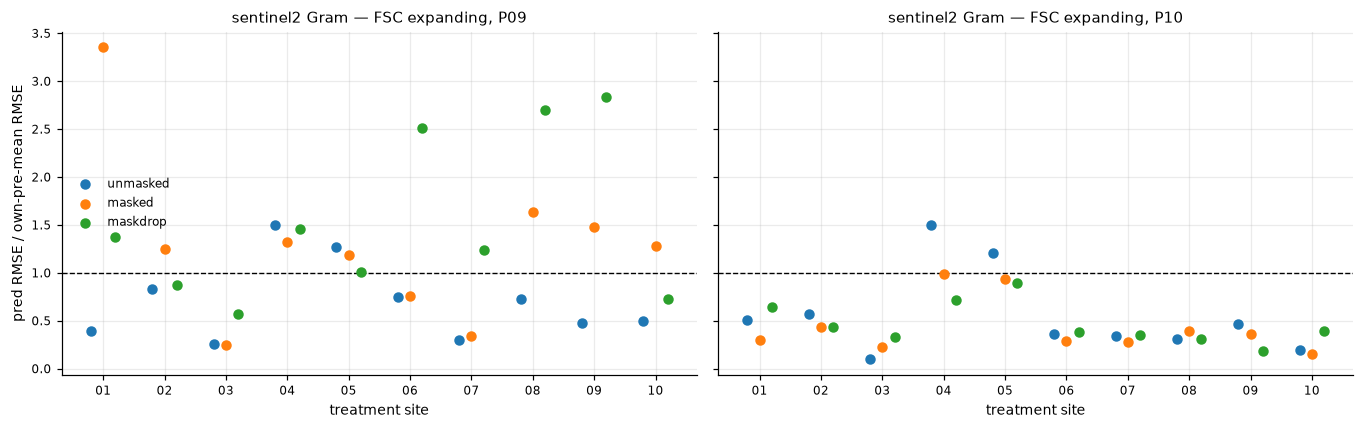

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.0), sharey=True)
for ax, per in zip(axes, ("P09", "P10")):
    sub = ex.query("estimator == 'fsc' and eval_period == @per")
    sites = sorted(sub.treatment_site_id.unique()); x = np.arange(len(sites))
    for i, lab in enumerate(["unmasked", "masked", "maskdrop"]):
        s = (sub.query("label == @lab and repr == 'gram'")
             .set_index("treatment_site_id").reindex(sites))
        ax.scatter(x + (i - 1) * 0.2, s["ratio_own_mean"], s=34, label=lab, zorder=4)
    ax.axhline(1.0, color="k", lw=0.9, ls="--")
    ax.set_xticks(x); ax.set_xticklabels([t[-2:] for t in sites])
    ax.set_xlabel("treatment site")
    ax.set_title(f"{SENSOR} Gram — FSC expanding, {per}")
axes[0].set_ylabel("pred RMSE / own-pre-mean RMSE")
axes[0].legend(frameon=False, fontsize=8)
fig.tight_layout(); fig.savefig("panel_masked_fsc_ratio.png", bbox_inches="tight")

MET.to_csv("panel_masked_fsc_validation.csv", index=False)
PLACEBO.to_csv("panel_masked_fsc_placebo.csv", index=False)
PSUM.to_csv("panel_masked_fsc_placebo_summary.csv", index=False)
info.to_csv("panel_masked_fallback_info.csv", index=False)
pd.concat([RUNS[("maskdrop", n)]["group_meta"].assign(repr=n) for n in REPRS],
          ignore_index=True).to_csv("panel_maskdrop_group_meta.csv", index=False)
pd.concat([RUNS[("maskdrop", n)]["weights"] for n in REPRS],
          ignore_index=True).to_csv("panel_maskdrop_weights.csv", index=False)
print("wrote panel_masked_* / panel_maskdrop_* outputs")

## Reading

Scored in the project's canonical metric (standardized test RMSE, notebook 11,
`panel_collabstyle_masked_sites.csv`), Sentinel-2, Gram:

1. **Masked pooling is ≈ cost-free on average** — P09 0.625 → 0.654, P10 0.466 → 0.457 —
   and removes every fabricated pixel from the statistics. It is not a rescue.
2. **Per-site P09 moves both ways with cloud geometry**: removing the fill hurts where
   the valid sample is small or mismatched between treated and donors (site 01
   0.35 → 0.54, site 09 0.32 → 0.78) and helps where the fill was distorting
   (site 04 1.37 → 1.14, site 05 0.99 → 0.79, site 10 1.19 → 1.07). Sites clean on
   both sides (03, 06, 07) barely move — their scores are honest.
3. **Dropping near-fully-masked chips is uniformly worse** (P09 mean 1.16): discarding
   the P03/P06 chips costs more fit data than the fabricated content costs accuracy.
4. **Consequence**: the filled P09 evaluation mixes honest cells with fill-matching
   cells, and P09 was chosen as holdout only for being the last pre-hurricane
   fortnight. Validate on clean pre-periods; read effects at clean post-periods
   (P11, P12, P19, P20).
